# Rapport de Projet Deep Learning : Diagnostic du cancer de la peau

Saving page.png to page.png


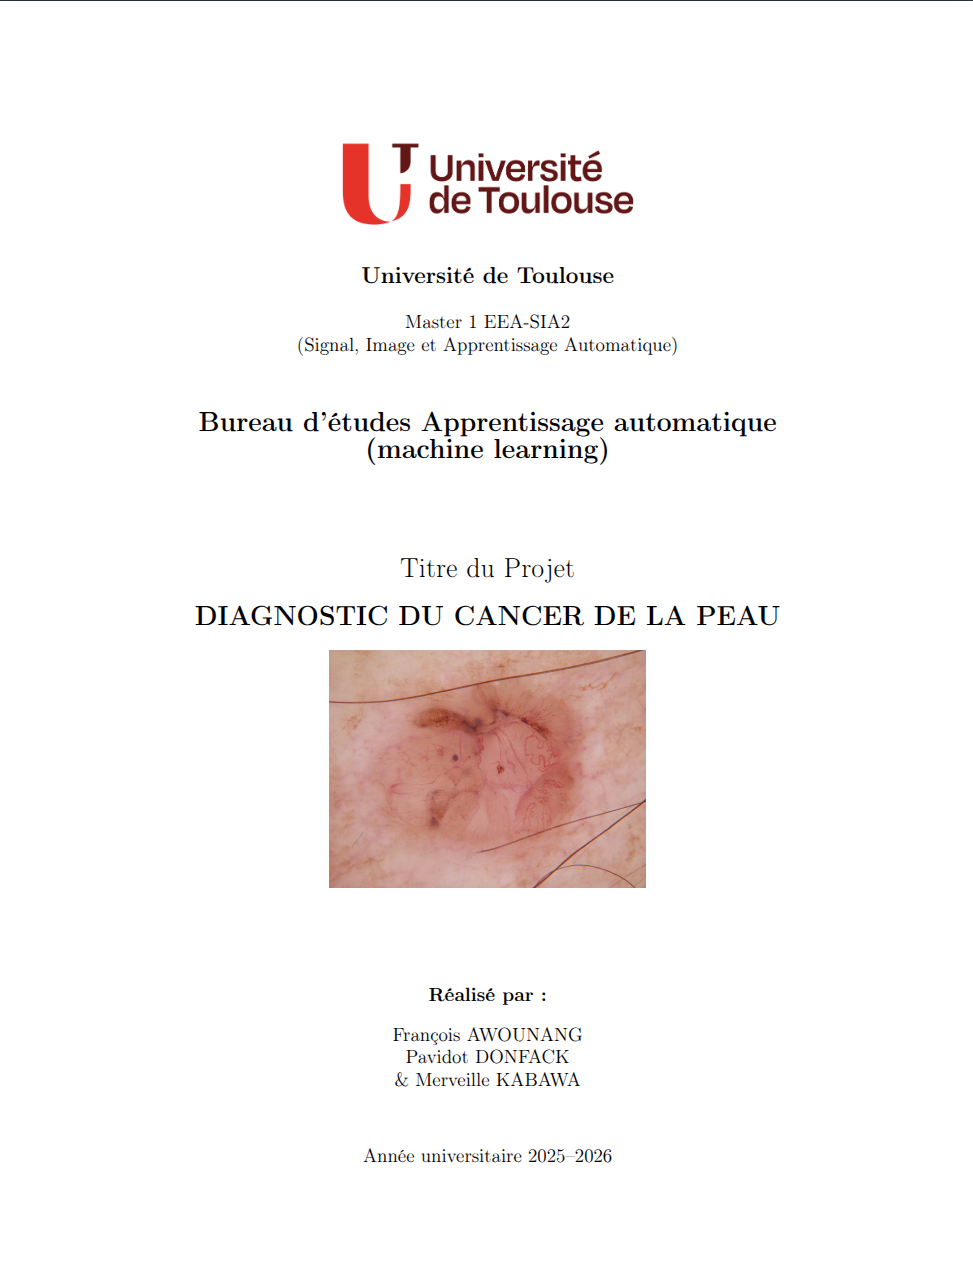

In [ ]:
from IPython.display import Image, display
display(Image('page.png'))
# est ce que l'image que tu met la est neccessaire ?

# **INTRODUCTION**

## Contexte

Ce projet est réalisé dans le cadre de notre formation de Master 1 EEA, parcours Signal, Image et Apprentissage Automatique. L’UE Bureau d’Étude – Apprentissage Automatique vise à nous familiariser avec les méthodes récentes d’apprentissage automatique, et plus particulièrement avec l’apprentissage profond (Deep Learning) basé sur les réseaux de neurones convolutifs.

C’est dans cette optique que nous avons travaillé sur l’élaboration d’un modèle capable de contribuer au diagnostic du cancer de la peau à partir d’images dermatoscopiques de patients.

## Problématique

Le diagnostic du cancer de la peau étant un problème courant en dermatologie, il est parfois très compliqué de pouvoir distinguer visuellement une catégorie de lésion et de l’attribuer à un type de cancer en particulier, car celles‑ci peuvent parfois être très similaires d’un type à l’autre et très différentes pour un même type. Il pourrait donc être très bénéfique de pouvoir automatiser cette classification afin d’optimiser le diagnostic, réduire les risques d’erreur et le temps d’analyse pour un dermatologue.

## Objectif du projet

Notre challenge est donc de pouvoir, d’une part, concevoir, entraîner et valider un modèle de Deep Learning qui va pouvoir classifier les types de lésions à partir d’images dermatoscopiques de patients, et d’autre part, à partir de cette classification, nous allons considérer :

- les lésions de type bénignes (non cancéreuses) comme « saines »

- et pour les lésions de type malignes (cancéreuses), prédire le type de cancer.

# Importation des Bibliotheques

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Nous commençons par importer l'ensemble des bibliothèques qui nous seront utiles tout au long de notre travail.

Le principal outil pour réaliser notre apprentissage est TensorFlow, développé par Google, il est basé sur le calcul tensoriel. Nous avons utilisé l'API Keras pour la construction de nos modèles, qui fournit plusieurs autres modules et des classes variées, tels que le module models et sa classe Sequential qui est adaptée pour notre problème de classification. Nous avons utilisé sa classe ImageDataGenerator pour notre prétraitement, son module callbacks pour la surveillance du modèle pendant l'entraînement. Nous avons également utilisé les bibliothèques Python telles que matplotlib et seaborn pour le tracé et la visualisation des données, splitfolders pour la répartition en train/val/test et Augmentor pour la data augmentation.

In [ ]:

import tensorflow as tf
from tensorflow.keras import datasets, layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import VGG16

from keras.models import Model
import seaborn as sns
from sklearn.metrics import confusion_matrix

import matplotlib.image as mpimg
%matplotlib inline
import os

# bibliothèque pour importer des images
from PIL import Image
import numpy as np
import cv2
from keras.models import Model

!pip install split-folders
!pip install Augmentor
import Augmentor
import splitfolders

# **Présentation de la base de données**


Pour la réalisation de ce projet, il nous a été fourni le dataset Skin Cancer de l’ISIC (International Skin Imaging Collaboration), qui est un partenariat entre le monde universitaire et le secteur privé visant à utiliser l’imagerie cutanée numérique pour contribuer à réduire la mortalité liée au cancer de la peau.

L’ensemble de la base de données était constitué de 2 357 images réparties en deux dossiers, test et train, avec chacun à l’intérieur 9 sous-dossiers correspondant à une catégorie de lésion. Les images sont en RVB, mais avec des taille diveferente, example: (1024*768), (600*450),

## Base de données fournie

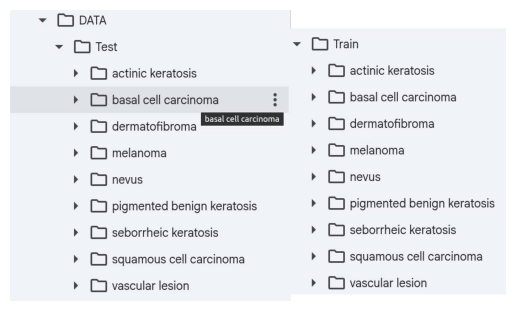

In [ ]:

# Chargement de l'image
img = mpimg.imread("/content/drive/MyDrive/Colab Notebooks/base.jpg")

# Affichage de l'image
plt.imshow(img)
plt.axis("off")  # enlève les axes
plt.show()

## Visualisation de quelques images dans chaque classe



Pour afficher une bonne visualisation de notre base de données, nous nous sommes fait aider par une IA, nous permettant de parcourir chaque classe et d’en afficher 5 images.

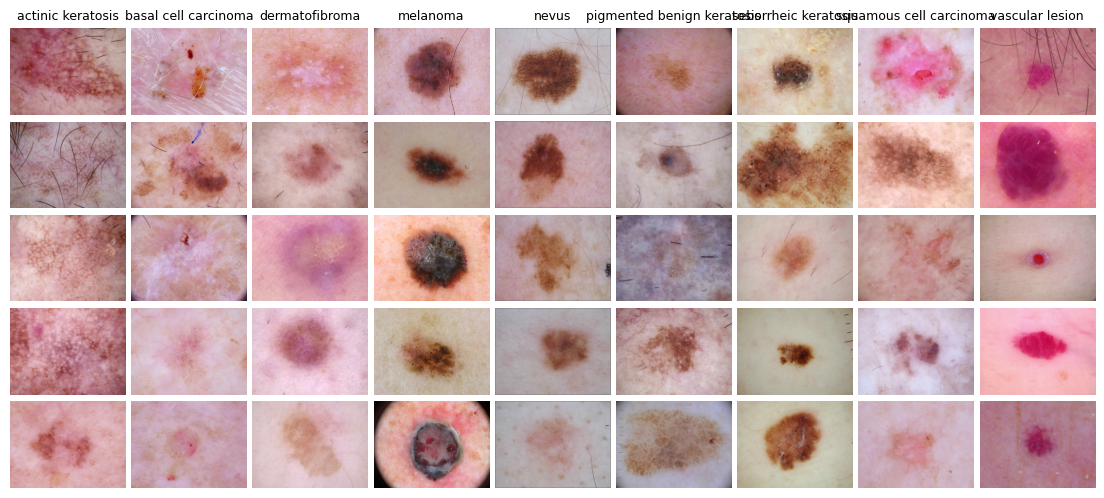

In [ ]:

data_dir = "/content/drive/MyDrive/Colab Notebooks/DATA/Train"

classes = sorted(os.listdir(data_dir))

fig, axes = plt.subplots(5, len(classes), figsize=(14, 6))

for j, classe in enumerate(classes):
    classe_dir = os.path.join(data_dir, classe)
    images = sorted(os.listdir(classe_dir))[:5]

    for i, img_name in enumerate(images):
        img = mpimg.imread(os.path.join(classe_dir, img_name))

        axes[i, j].imshow(img)
        axes[i, j].axis('off')

        if i == 0:
            axes[i, j].set_title(classe, fontsize=9)

# 🔧 Ajustement fin des espacements
plt.subplots_adjust(wspace=0.05, hspace=0.05)

plt.show()

Nous pouvons constater en visualisant le dataset qu'il est très varié dans les classes et présente certaines similitudes pour des classes différentes, ce qui peut rendre l'apprentissage du modèle difficile. En effet, pour une bonne classification il faudrait que la variance intraclasse soit la plus petite possible et que la variance interclasse soit la plus grande possible.

# **Modèle 1**

## Prétraitement du modèle 1


### Répartition de la base de train pour obtenir une validation


Notre base de données ayant été fournie avec un dossier d'entraînement et un dossier de test, nous allons diviser la base d'entraînement pour obtenir une base de validation, qui est utilisée pendant l'entraînement. Cette pratique qui consiste à extraire les données de validation directement depuis la base d'entraînement peut parfois s'avérer pénalisante, car on n'est pas certain de la représentativité de la répartition initiale des données. Dans un premier temps nous allons travailler avec cette approche afin d'en observer les conséquences.
Pour le jeu d'entraînement initial, nous effectuons une répartition de 80% pour le nouvel ensemble d'entraînement et 20% pour la validation.

In [ ]:

# divitsion de la base de donnée en train test et validation

data_dir = "/content/drive/MyDrive/Colab Notebooks/DATA/Train/"
output_dir = "/content/drive/MyDrive/Colab Notebooks/DATA_SPLIT/"

splitfolders.ratio(data_dir, output_dir, seed=1337, ratio=(.8, 0.2))

Copying files: 2239 files [02:06, 17.76 files/s]


### Opérations de prétraitement

Le prétraitement consiste à appliquer des transformations préliminaires sur les données, visant à les uniformiser ou à les ramener sous une forme facilement exploitable par le modèle. Nous utilisons pour cet effet la classe ImageDataGenerator du sous-module preprocessing.image de Keras. Étant donné que nous avons constaté des tailles différentes dans le dataset, il est important de toutes les ramener à une même taille pour l'entrée de notre modèle. En perspective de l'utilisation du modèle pré-entraîné VGG16, nous partons sur une taille minimale de 224×224 pixels. Il est important de noter également que pour obtenir à chaque exécution le même ordre des données, il faut fixer le seed qui représente la graine aléatoire, un peu à l'image de la fonction rand de MATLAB à laquelle on fixe une graine. Le paramètre shuffle assigné à False permet de maintenir le même ordre de sélection des images dans les dossiers, ce qui est important pour le jeu de test, car l'idée est d'obtenir le même résultat pour plusieurs exécutions avec un même modèle. Lorsque shuffle est assigné à True, les données sont mélangées aléatoirement avant d'être envoyées par paquets au modèle via le batch_size de 32. Enfin, notre mode de classification étant multi-classes, l'option categorical permet d'encoder les labels en one-hot, garantissant ainsi qu'un seul label soit actif parmi les 9 en sortie.

In [ ]:

#### pretraitement des donnees
datagen = ImageDataGenerator(rescale=1./255)

##

train_generator=datagen.flow_from_directory(
    directory ="/content/drive/MyDrive/Colab Notebooks/DATA_SPLIT/train",
    batch_size=32,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode="categorical",
    shuffle=True,
    seed=42
    )

test_generator=datagen.flow_from_directory(
    directory ="/content/drive/MyDrive/Colab Notebooks/DATA/Test",
    batch_size=32,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode="categorical",
    shuffle=False,
    seed=42
    )


val_generator=datagen.flow_from_directory(
    directory ="/content/drive/MyDrive/Colab Notebooks/DATA_SPLIT/val",
    batch_size=32,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode="categorical",
    shuffle=True,
    seed=42
    )

Found 1787 images belonging to 9 classes.
Found 118 images belonging to 9 classes.
Found 452 images belonging to 9 classes.


##  Architecture Modèle *1*

Pour ce premier modèle, nous partons sur une architecture minimale que nous allons améliorer au fur et à mesure. Nous avons donc mis un seul filtre de taille (3 × 3) dans la couche de convolution ; c’est de cette couche que découle le nom de réseau de neurones convolutif, car il se base essentiellement sur les opérations de convolution pour l’extraction de caractéristiques, suivie d’un MaxPooling2D pour extraire l’information la plus importante afin de pouvoir généraliser.

Elle est ensuite suivie d’une couche Flatten qui redimensionne les cartes de caractéristiques issues du max pooling en un seul vecteur, permettant ainsi de les relier à une couche entièrement connectée « Dense ». Si nous revenons à la couche de convolution, son argument padding, dans notre cas « same », permet d’effectuer un zero padding lors de la convolution, remplaçant ainsi les pixels vides par des zéros afin de conserver la même taille d’image en sortie. En revanche, son argument activation, configuré sur ReLU ici, permet d’établir une relation non linéaire.

In [ ]:

#construction du model
model = models.Sequential()

# CONV => RELU => POOL
model.add(layers.Convolution2D(1, (3, 3), padding= 'same',
           input_shape=(224, 224, 3), activation='relu'))

model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# Flatten
model.add(layers.Flatten())

# numbre de lessions = nombre de classes
NB_CLASSES = 9

# softmax dense classifier
model.add(layers.Dense(NB_CLASSES, activation="softmax"))

# summary of the model
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 1)    │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │       112,905 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,933 (441.14 KB)

 Trainable params: 112,933 (441.14 KB)

 Non-trainable params: 0 (0.00 B)

Ce premier modèle contient au total 112 933 paramètres, dont la grande majorité provient de la couche de sortie qui multiplie les 12 544 paramètres issus du Flatten par les 9 classes. La fonction d'activation softmax permet ainsi d'assigner la plus grande probabilité en sortie comme étant la classe à laquelle appartient l'image d'entrée.

## Compilation Modèle 1

In [ ]:
# compilation du model
model.compile(optimizer='SGD', loss='categorical_crossentropy',
              metrics=['accuracy'])

## Entraînement du Modèle 1


In [ ]:

#Nombre d'epochs
EPOCHS = 5

model.fit(train_generator, epochs=EPOCHS,verbose=1 ,validation_data=val_generator)


Epoch 1/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 42s 721ms/step - accuracy: 0.1802 - loss: 4.5067 - val_accuracy: 0.2058 - val_loss: 2.1778
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 34s 612ms/step - accuracy: 0.2037 - loss: 2.1685 - val_accuracy: 0.2058 - val_loss: 2.1595
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 38s 678ms/step - accuracy: 0.2065 - loss: 2.1512 - val_accuracy: 0.2058 - val_loss: 2.1433
Epoch 4/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 34s 612ms/step - accuracy: 0.2065 - loss: 2.1359 - val_accuracy: 0.2058 - val_loss: 2.1291
Epoch 5/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 34s 601ms/step - accuracy: 0.2065 - loss: 2.1223 - val_accuracy: 0.2058 - val_loss: 2.1165


## Evaluation Modèle 1

In [ ]:

#evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print('Test accuracy:', test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.1356 - loss: 2.1764
Test accuracy: 0.1355932205915451


Comme on aurait pu s'en douter, ce premier modèle montre de très mauvaises performances avec une accuracy de 13% sur le jeu de test, ce qui était tout à fait prévisible car un seul filtre dans la couche de convolution n'est pas suffisant pour extraire l'ensemble des caractéristiques discriminantes des images. Pour la suite, nous allons donc partir sur une architecture plus robuste.

# **Modèle 2**

Pour ce deuxième modèle, afin d'augmenter la capacité du modèle à extraire les caractéristiques discriminantes, nous avons ajouté une deuxième couche de convolution suivie d'une couche de MaxPooling, avec respectivement 32 et 50 filtres pour les deux couches de convolution. Une fois les caractéristiques extraites, l'enjeu est de pouvoir effectuer une bonne classification. Nous ajoutons donc une couche Dense intermédiaire servant à apprendre les combinaisons des caractéristiques extraites, suivie d'un Dropout qui va désactiver aléatoirement 50% des neurones à chaque batch, évitant ainsi que le modèle apprenne par cœur chaque détail des données d'entraînement.

## Architecture Modèle 2

In [ ]:

# number of outputs = number of digits
NB_CLASSES = 9
#build the model
model = models.Sequential()
# CONV => RELU => POOL
model.add(layers.Convolution2D(32, (3, 3), padding= 'same',
           input_shape=(224, 224, 3), activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

model.add(layers.Convolution2D(50, (3, 3), padding= 'same',
           input_shape=(224, 224, 3), activation='relu'))

model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# Flatten
model.add(layers.Flatten())
# softmax dense classifier

model.add(layers.Dense(500, activation="relu"))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(NB_CLASSES, activation="softmax"))

# summary of the model
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 50)   │        14,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 156800)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │    78,400,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         4,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,420,355 (299.15 MB)

 Trainable params: 78,420,355 (299.15 MB)

 Non-trainable params: 0 (0.00 B)

L’ensemble des modifications apportées a fait croître considérablement le nombre de paramètres à 78 420 355, mais un nombre de paramètres plus élevé ne suffit pas toujours à rendre un modèle plus performant.


## Compilation Modèle 2

In [ ]:
# compiling the model
model.compile(optimizer='SGD', loss='categorical_crossentropy',metrics=['accuracy'])


## Entraînement plus long Modèle 2, avec early stoping

Pour l'entraînement de ce deuxième modèle, nous avons utilisé la classe EarlyStopping du module callbacks de Keras, consistant à arrêter automatiquement l'entraînement lorsque le modèle tend vers un overfitting.

In [ ]:

#training the model
EPOCHS = 50

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

history=model.fit(train_generator, epochs=EPOCHS,verbose=1 ,validation_data=val_generator,callbacks=[es])
print(history.history.keys())

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1493s 27s/step - accuracy: 0.2143 - loss: 2.0572 - val_accuracy: 0.1947 - val_loss: 2.0337
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 494ms/step - accuracy: 0.2602 - loss: 2.0001 - val_accuracy: 0.1969 - val_loss: 1.9686
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 487ms/step - accuracy: 0.2781 - loss: 1.9490 - val_accuracy: 0.4248 - val_loss: 1.8533
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 490ms/step - accuracy: 0.2994 - loss: 1.8921 - val_accuracy: 0.2788 - val_loss: 1.9301
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 503ms/step - accuracy: 0.3223 - loss: 1.8594 - val_accuracy: 0.3695 - val_loss: 1.7516
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 489ms/step - accuracy: 0.3324 - loss: 1.8301 - val_accuracy: 0.4580 - val_loss: 1.6981
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 493ms/step - accuracy: 0.3643 - loss: 1.7569 - val_accuracy: 0.2987 - val_loss: 1.8364
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 495ms/step - accuracy: 0.3542 - loss: 1.7622 - val_accu

## Evaluation Modèle 2

In [ ]:

#evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print('Test accuracy:', test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 49s 11s/step - accuracy: 0.3559 - loss: 2.2459
Test accuracy: 0.35593220591545105


Nous constatons une progrssio dans les performence du modele de 13% a 35%

<BarContainer object of 2 artists>

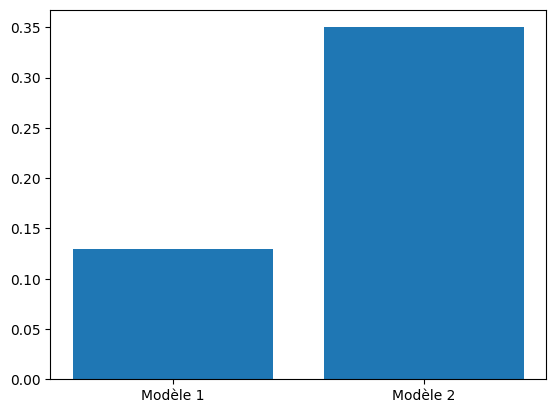

In [ ]:
# Comparaisons des deux modèles
modeles = ['Modèle 1', 'Modèle 2']
test_acc = [0.13, 0.35]
plt.bar(modeles, test_acc, label='accuracy', align='center' )

## Analyse des courbes de l’entraînement du modèle 2


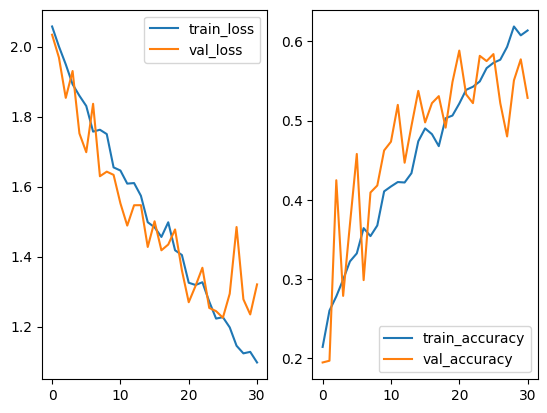

In [ ]:
#tracer des courbes
plt.figure()
plt.subplot(121)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()


plt.subplot(122)
plt.plot(history.history['accuracy'], label='train_accuracy' )
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()


Pour ce deuxième modèle, nous avons constaté une amélioration de la précision sur les données de test, avec la métrique accuracy qui est passée de 13 % à 35 %. Nous constatons, en analysant les courbes enregistrées lors de l’entraînement, que les performances sur les données de validation suivent assez bien celles des données d’entraînement ; l'on pourais croire que le modèle parvient à bien généraliser mais ce resultat est enfait trompeur car la base de validation est un peu surepresenté. Cependant, il existe egqlement un écart notable entre les performances pendant l’entraînement et celles sur les données de test : l’accuracy atteint un pic de 58 % sur la validation mais chute à 35 % sur les données de test, ce qui pourrait s’expliquer par le fait que les données de test ne soient pas assez représentatives du jeu de données.


## Mauvaise représentation de la base de test


La répartition initiale de la base de données pose problème : ayant utilisé le jeu de test tel que fourni par le dataset, il présente un nombre total de 118 images, soit seulement 5% du dataset. Notre division du jeu d'entraînement initial a conduit à 452 images pour la validation, soit 19%, et environ 76% pour l'entraînement. On se rend compte effectivement qu'avec cette répartition, le jeu de test n'est pas assez représentatif. Nous illustrons cela sur le diagramme circulaire ci-dessous.


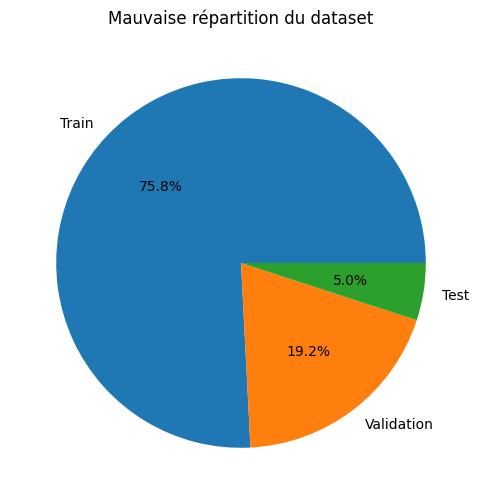

In [ ]:

elements = ['Train', 'Validation', 'Test']
taille  = [1787, 452, 118]

plt.figure(figsize=(6, 6))
plt.pie(taille, labels=elements, autopct='%1.1f%%')
plt.title('Mauvaise répartition du dataset')
plt.show()

# Modèle 3

## Nouveau prétraitement avec un dataset fusionné

In [ ]:
# divitsion de la base de donne en train test et validation

data_dir = "/content/drive/MyDrive/Colab Notebooks/DATA2/"
output_dir = "/content/drive/MyDrive/Colab Notebooks/DATA_SPLIT2/"

splitfolders.ratio(data_dir, output_dir, seed=1337, ratio=(.8, 0.1, 0.1))

Copying files: 2357 files [04:19,  9.07 files/s]


Nous avons fusionné manuellement notre base de données initiale afin de réunir toutes les images en 9 classes distinctes et de faire une nouvelle répartition en données d’entraînement, de validation et de test.


In [ ]:

elements = ['Train', 'Validation', 'Test']
taille  = [1787, 452, 118]

plt.figure(figsize=(6, 6))
plt.pie(taille, labels=elements, autopct='%1.1f%%')
plt.title('Mauvaise répartition du dataset')
plt.show()

## Nouveau prétraitement sur la nouvelle répartition

In [ ]:

#### pretraitement des donnees
datagen = ImageDataGenerator(rescale=1./255)

##

train_generator=datagen.flow_from_directory(
    directory ="/content/drive/MyDrive/Colab Notebooks/DATA_SPLIT2/train",
    batch_size=32,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode="categorical",
    shuffle=True,
    seed=42
    )

test_generator=datagen.flow_from_directory(
    directory ="/content/drive/MyDrive/Colab Notebooks/DATA_SPLIT2/test",
    batch_size=32,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode="categorical",
    shuffle=False,
    seed=42
    )


val_generator=datagen.flow_from_directory(
    directory ="/content/drive/MyDrive/Colab Notebooks/DATA_SPLIT2/val",
    batch_size=32,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode="categorical",
    shuffle=True,
    seed=42
    )

Found 1882 images belonging to 9 classes.
Found 242 images belonging to 9 classes.
Found 233 images belonging to 9 classes.


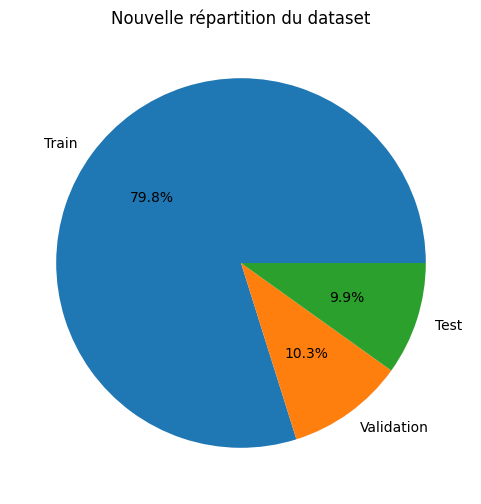

In [ ]:

elements = ['Train', 'Validation', 'Test']
taille  = [1882, 242, 233]

plt.figure(figsize=(6, 6))
plt.pie(taille, labels=elements, autopct='%1.1f%%')
plt.title('Nouvelle répartition du dataset')
plt.show()

## Architecture et entraînement du modèle 3 avec la même configuration que le modèle 2


In [ ]:
# number of outputs = number of digits
NB_CLASSES = 9
#build the model
model = models.Sequential()
# CONV => RELU => POOL
model.add(layers.Convolution2D(32, (3, 3), padding= 'same',
           input_shape=(224, 224, 3), activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

model.add(layers.Convolution2D(50, (3, 3), padding= 'same',
           input_shape=(224, 224, 3), activation='relu'))

model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# Flatten
model.add(layers.Flatten())
# softmax dense classifier

model.add(layers.Dense(500, activation="relu"))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(NB_CLASSES, activation="softmax"))

# summary of the model
#model.summary()

# compiling the model
model.compile(optimizer='SGD', loss='categorical_crossentropy',metrics=['accuracy'])

#training the model
EPOCHS = 50

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

history=model.fit(train_generator, epochs=EPOCHS,verbose=1 ,validation_data=val_generator,callbacks=[es])
print(history.history.keys())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 42s 678ms/step - accuracy: 0.2274 - loss: 2.0599 - val_accuracy: 0.1974 - val_loss: 2.0615
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 31s 533ms/step - accuracy: 0.2885 - loss: 1.9696 - val_accuracy: 0.2361 - val_loss: 1.9453
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 30s 519ms/step - accuracy: 0.2891 - loss: 1.9303 - val_accuracy: 0.3133 - val_loss: 1.8633
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 33s 560ms/step - accuracy: 0.3140 - loss: 1.8851 - val_accuracy: 0.3047 - val_loss: 1.8918
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 34s 574ms/step - accuracy: 0.3177 - loss: 1.8506 - val_accuracy: 0.3047 - val_loss: 1.8390
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 32s 549ms/step - accuracy: 0.3565 - loss: 1.7739 - val_accuracy: 0.2747 - val_loss: 1.9320
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 31s 520ms/step - accuracy: 0.3757 - loss: 1.7525 - val_accuracy: 0.4249 - val_loss: 1.7204
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 30s 514ms/step - accuracy: 0.4150 - loss: 1.6729 - val_accu

## Évaluation et analyse des courbes d’accuracy/loss du modèle 3


8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 502ms/step - accuracy: 0.5413 - loss: 1.3251
Test accuracy: 0.5413222908973694


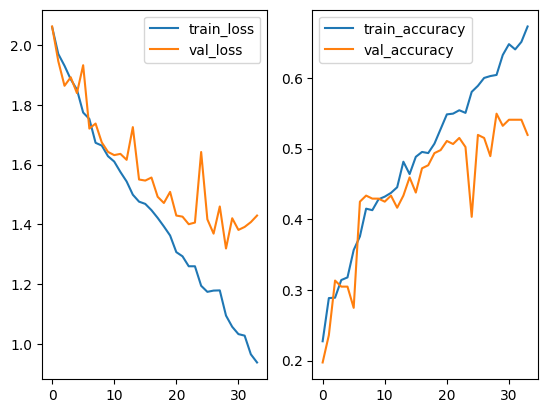

In [ ]:
#evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print('Test accuracy:', test_acc)

#tracer des courbes
plt.figure()
plt.subplot(121)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()


plt.subplot(122)
plt.plot(history.history['accuracy'], label='train_accuracy' )
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Evolution des modèles')

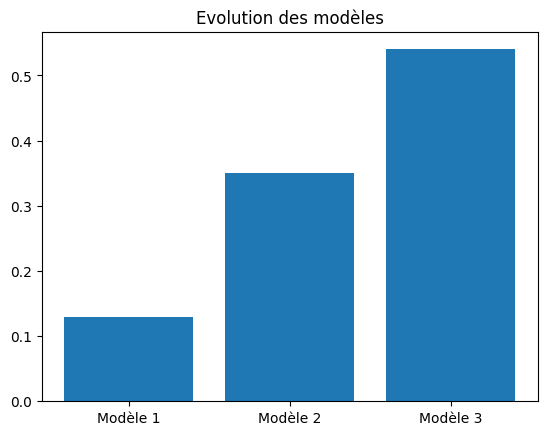

In [ ]:
# Evolution des trois modèles
plt.bar(['Modèle 1', 'Modèle 2', 'Modèle 3'], [0.13, 0.35, 0.54], label='test_acc', align='center')
plt.title('Evolution des modèles')

Nous constatons que le modèle 3 obtient de meilleures performances sur les données de test avec une accuracy de 54,13%, qui est d'autant plus proche des données de validation à 54,94%, ce qui confirme que le nouveau split 80/10/10 est plus représentatif. Cependant, on observe un écart important entre les performances d'entraînement et de validation sur les courbes d'accuracy et de loss, ce qui suggère que le modèle ne parvient pas encore à bien généraliser. De plus, les courbes montrent que le modèle n'a pas encore convergé, laissant penser que les performances pourraient encore être améliorées.

Nous allons donc, dans le modèle 4, essayer de faire du transfer learning avec un modèle qui a été entraîné sur de grandes quantités d’images.


# Modèle 4

Nous avons donc repris la configuration du modèle 3 et ajouté des couches de Batch Normalization entre les couches de convolution et de max pooling.


In [ ]:
# number of outputs = number of digits
NB_CLASSES = 9
#build the model
model = models.Sequential()
# CONV => RELU => POOL
model.add(layers.Convolution2D(32, (3, 3), padding= 'same',
           input_shape=(224, 224, 3), activation='relu'))

# Ajout d'une couche de Batch normalization
model.add(layers.BatchNormalization())

model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

model.add(layers.Convolution2D(50, (3, 3), padding= 'same',
           input_shape=(224, 224, 3), activation='relu'))

# Ajout d'une couche de Batch normalization
model.add(layers.BatchNormalization())

model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# Flatten
model.add(layers.Flatten())
# softmax dense classifier

model.add(layers.Dense(500, activation="relu"))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(NB_CLASSES, activation="softmax"))

# summary of the model
#model.summary()

# compiling the model
model.compile(optimizer='SGD', loss='categorical_crossentropy',metrics=['accuracy'])

#training the model
EPOCHS = 50

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

history=model.fit(train_generator, epochs=EPOCHS,verbose=1 ,validation_data=val_generator,callbacks=[es])
print(history.history.keys())

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 38s 588ms/step - accuracy: 0.2774 - loss: 10.2661 - val_accuracy: 0.1674 - val_loss: 4.3940
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 32s 547ms/step - accuracy: 0.3932 - loss: 2.0497 - val_accuracy: 0.1674 - val_loss: 6.0135
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 32s 530ms/step - accuracy: 0.4649 - loss: 1.5701 - val_accuracy: 0.1760 - val_loss: 7.3468
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 31s 524ms/step - accuracy: 0.5043 - loss: 1.4610 - val_accuracy: 0.3004 - val_loss: 4.9440
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 31s 533ms/step - accuracy: 0.5383 - loss: 1.3171 - val_accuracy: 0.3219 - val_loss: 3.7703
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 33s 563ms/step - accuracy: 0.5685 - loss: 1.2473 - val_accuracy: 0.3605 - val_loss: 3.2764
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 31s 526ms/step - accuracy: 0.5978 - loss: 1.1428 - val_accuracy: 0.3605 - val_loss: 2.5209
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 31s 528ms/step - accuracy: 0.6137 - loss: 1.1341 - val_acc

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 396ms/step - accuracy: 0.4917 - loss: 1.8129
Test accuracy: 0.4917355477809906


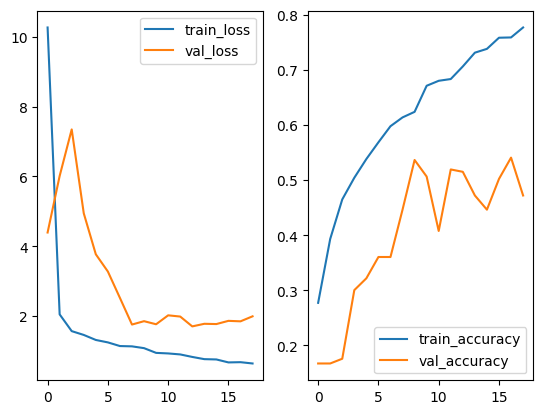

In [ ]:
#evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print('Test accuracy:', test_acc)

#tracer des courbes
plt.figure()
plt.subplot(121)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()


plt.subplot(122)
plt.plot(history.history['accuracy'], label='train_accuracy' )
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

# Modèle 4: Trensfert Learning avec VGG16

## Modèle VGG16 : couches d’extraction de caractéristiques.


Nous allons utiliser les couches convolutives du modèle qui ont déjà été entraînées pour extraire des caractéristiques sur des millions d’images. Nous gardons, dans un premier temps, toutes ces couches convolutives avec les mêmes paramètres.


In [ ]:
# nouveau model avec un model deja entainé

base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
# Include_top=False: pour choisir uniquement les couches convolutives
# weights='imagenet': pour choisir les paramètres entraînés avec la base ImageNet

# Pour que les paramètres des couches convolutives ne soient pas modifies.
base_model.trainable = False

# resumer des parametres
base_model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## Complément de l’architecture avec nos couches Dense pour la classification

Étant donné que nous avons repris la première partie du modèle pré-entraîné qui se spécialise dans l’extraction de caractéristiques, nous le complétons maintenant avec nos couches Dense qui vont être entraînées à faire de la classification.

Entraînement avec les données redistribuées, on réexécute la cellule de prétraitement qui se trouve dans le modèle 3

In [ ]:
# numbre de lessions = nombre de classes
NB_CLASSES = 9

model = models.Sequential([
 base_model,
 layers.Flatten(),
 layers.Dense(500, activation='relu'),
 layers.Dropout(0.5),
 layers.Dense(NB_CLASSES, activation='softmax')])


# # compiling the model
model.compile(optimizer='SGD', loss='categorical_crossentropy',metrics=['accuracy'])


#training the model
EPOCHS = 50

##################################################################

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

history=model.fit(train_generator, epochs=EPOCHS,verbose=1 ,validation_data=val_generator,callbacks=[es])
print(history.history.keys())

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 746s 13s/step - accuracy: 0.1854 - loss: 2.3369 - val_accuracy: 0.1974 - val_loss: 2.0396
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 34s 583ms/step - accuracy: 0.1844 - loss: 2.0746 - val_accuracy: 0.1974 - val_loss: 2.0399
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 33s 565ms/step - accuracy: 0.1945 - loss: 2.0643 - val_accuracy: 0.1588 - val_loss: 2.1025
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 33s 564ms/step - accuracy: 0.1886 - loss: 2.0515 - val_accuracy: 0.1931 - val_loss: 2.0227
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 33s 567ms/step - accuracy: 0.1886 - loss: 2.0452 - val_accuracy: 0.2017 - val_loss: 2.0311
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 34s 569ms/step - accuracy: 0.2019 - loss: 2.0381 - val_accuracy: 0.2017 - val_loss: 2.0075
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 33s 552ms/step - accuracy: 0.2109 - loss: 2.0255 - val_accuracy: 0.2017 - val_loss: 1.9885
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 33s 553ms/step - accuracy: 0.2179 - loss: 2.0112 - val_accur

## Évaluation et analyse du transfer learning avec VGG16

8/8 ━━━━━━━━━━━━━━━━━━━━ 81s 12s/step - accuracy: 0.2149 - loss: 1.8568
Test accuracy: 0.21487602591514587


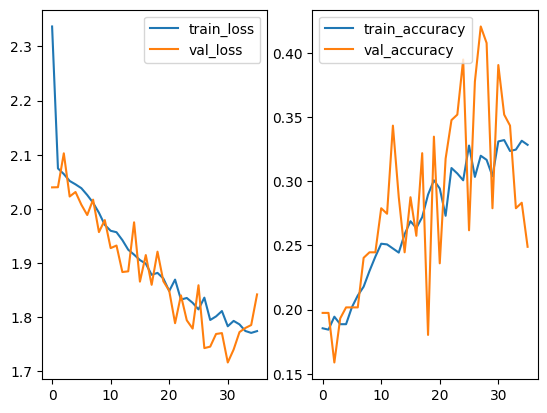

In [ ]:
#evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print('Test accuracy:', test_acc)

#tracer des courbes
plt.figure()
plt.subplot(121)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()


plt.subplot(122)
plt.plot(history.history['accuracy'], label='train_accuracy' )
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Evolution des modèles')

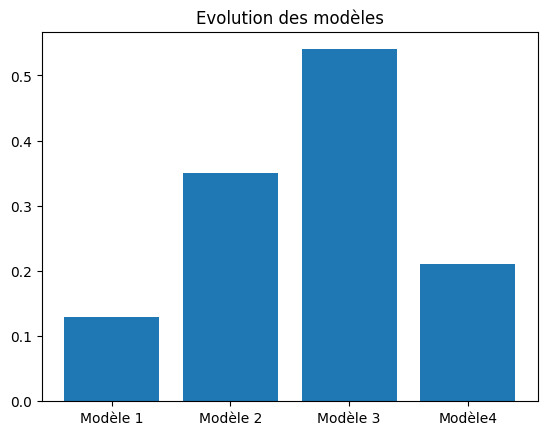

In [ ]:
# Evolution des 4 modèles
#import matplotlib.pyplot as plt
plt.bar(['Modèle 1', 'Modèle 2', 'Modèle 3', 'Modèle4'], [0.13, 0.35, 0.54, 0.21], label='test_acc', align='center')
plt.title('Evolution des modèles')

Nous constatons que nous avons perdu en performance car l'accuracy sur les données de test est passée de 54,13% à 21%. De plus, les oscillations sont beaucoup plus marquées, suggérant un apprentissage instable. En effet, bien que le modèle ait été entraîné à reconnaître des millions d'images, il n'est pas suffisamment adapté pour des applications aussi spécifiques que la classification d'images de lésions cutanées, car ses couches convolutives restent figées sur des caractéristiques extraites depuis ImageNet.


Nous allons donc essayer dans le modèle 5 de dégeler certaines couches du modèle VGG16, opération appelée fine-tuning, afin qu'il extraie des caractéristiques propres à notre dataset.


# Modèle 5: Affinage du modèle VGG16

Nous allons à présent une nouvelle fois partir du modèle pré-entraîné VGG16, mais cette fois-ci débloquer les deux dernières couches de convolution pour les réentraîner sur notre propre base de données, qui est différente de la base de données d’entraînement ImageNet du modèle VGG16 : cette opération est appelée affinage du modèle (fine-tuning).


## Couches entraînables


In [ ]:

# nouveau model avec finiTuning

base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
# Include_top=False: pour choisir uniquement les couches convolutives
# weights='imagenet': pour choisir les paramètres entraînés avec la base ImageNet



# Les paramètres des 17 premières couches sont gelés
for layer in base_model.layers[:17]:
    layer.trainable = False


# Pour voir quelles sont les couches entraînables
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.trainable)



0 input_layer_3 False
1 block1_conv1 False
2 block1_conv2 False
3 block1_pool False
4 block2_conv1 False
5 block2_conv2 False
6 block2_pool False
7 block3_conv1 False
8 block3_conv2 False
9 block3_conv3 False
10 block3_pool False
11 block4_conv1 False
12 block4_conv2 False
13 block4_conv3 False
14 block4_pool False
15 block5_conv1 False
16 block5_conv2 False
17 block5_conv3 True
18 block5_pool True


## Complément du modèle et entraînement


Nous avons de nouveau complementer le modele avec les couches denses et nous avons ajouter

In [ ]:
# numbre de lessions = nombre de classes
NB_CLASSES = 9

model = models.Sequential([
 base_model,
 layers.Flatten(),
 layers.Dense(500, activation='relu'),
 layers.Dropout(0.5),
 layers.Dense(NB_CLASSES, activation='softmax')
])

# # compiling the model
model.compile(optimizer='SGD', loss='categorical_crossentropy',metrics=['accuracy'])


#training the model
EPOCHS = 50


##################################################################

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

callbacks = [es, model_checkpoint];

history=model.fit(train_generator, epochs=EPOCHS,verbose=1 ,validation_data=val_generator,callbacks=callbacks)
print(history.history.keys())

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.1891 - loss: 2.8652

59/59 ━━━━━━━━━━━━━━━━━━━━ 43s 668ms/step - accuracy: 0.2040 - loss: 2.3113 - val_accuracy: 0.2489 - val_loss: 1.9624
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.2777 - loss: 1.9432

59/59 ━━━━━━━━━━━━━━━━━━━━ 33s 557ms/step - accuracy: 0.2944 - loss: 1.9142 - val_accuracy: 0.3090 - val_loss: 1.8230
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.3684 - loss: 1.7730

59/59 ━━━━━━━━━━━━━━━━━━━━ 32s 550ms/step - accuracy: 0.3645 - loss: 1.7757 - val_accuracy: 0.4549 - val_loss: 1.7044
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.3929 - loss: 1.6821

59/59 ━━━━━━━━━━━━━━━━━━━━ 36s 598ms/step - accuracy: 0.4155 - loss: 1.6384 - val_accuracy: 0.4592 - val_loss: 1.6355
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.4497 - loss: 1.5352

...

59/59 ━━━━━━━━━━━━━━━━━━━━ 33s 554ms/step - accuracy: 0.5717 - loss: 1.2327 - val_accuracy: 0.5064 - val_loss: 1.4216
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.5960 - loss: 1.1734

59/59 ━━━━━━━━━━━━━━━━━━━━ 34s 571ms/step - accuracy: 0.6036 - loss: 1.1513 - val_accuracy: 0.5494 - val_loss: 1.3598
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 34s 583ms/step - accuracy: 0.6126 - loss: 1.1101 - val_accuracy: 0.4077 - val_loss: 1.5989
Epoch 12/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 39s 550ms/step - accuracy: 0.6281 - loss: 1.0751 - val_accuracy: 0.5279 - val_loss: 1.4096
Epoch 13/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 34s 558ms/step - accuracy: 0.6504 - loss: 0.9958 - val_accuracy: 0.5365 - val_loss: 1.3675
Epoch 14/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.6848 - loss: 0.9412

59/59 ━━━━━━━━━━━━━━━━━━━━ 32s 549ms/step - accuracy: 0.6732 - loss: 0.9417 - val_accuracy: 0.5494 - val_loss: 1.3113
Epoch 15/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 32s 540ms/step - accuracy: 0.6934 - loss: 0.9042 - val_accuracy: 0.5279 - val_loss: 1.3375
Epoch 16/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.6939 - loss: 0.8741

59/59 ━━━━━━━━━━━━━━━━━━━━ 36s 610ms/step - accuracy: 0.7024 - loss: 0.8732 - val_accuracy: 0.5665 - val_loss: 1.3063
Epoch 17/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.7328 - loss: 0.8259

59/59 ━━━━━━━━━━━━━━━━━━━━ 33s 565ms/step - accuracy: 0.7163 - loss: 0.8320 - val_accuracy: 0.5579 - val_loss: 1.2809
Epoch 18/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 35s 592ms/step - accuracy: 0.7380 - loss: 0.7769 - val_accuracy: 0.5322 - val_loss: 1.3705
Epoch 19/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 38s 549ms/step - accuracy: 0.7476 - loss: 0.7537 - val_accuracy: 0.5193 - val_loss: 1.3969
Epoch 20/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 36s 608ms/step - accuracy: 0.7657 - loss: 0.6943 - val_accuracy: 0.5622 - val_loss: 1.3211
Epoch 21/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 34s 568ms/step - accuracy: 0.7752 - loss: 0.6847 - val_accuracy: 0.5451 - val_loss: 1.3966
Epoch 22/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 33s 547ms/step - accuracy: 0.7827 - loss: 0.6299 - val_accuracy: 0.5622 - val_loss: 1.2831
Epoch 22: early stopping
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## Évaluation et analyse du fine-tuning avec VGG16


8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 526ms/step - accuracy: 0.5496 - loss: 1.2453
Test accuracy: 0.5495867729187012


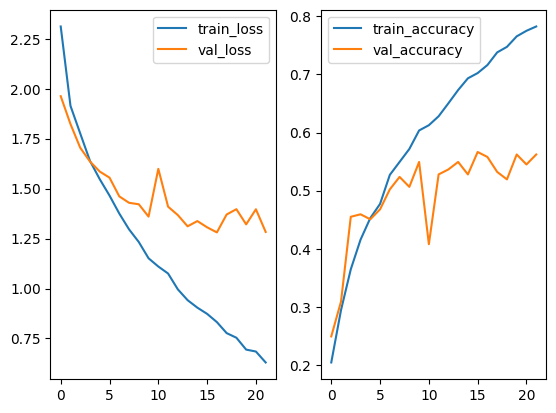

In [ ]:
#evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print('Test accuracy:', test_acc)

#tracer des courbes
plt.figure()
plt.subplot(121)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()


plt.subplot(122)
plt.plot(history.history['accuracy'], label='train_accuracy' )
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Evolution des modèles')

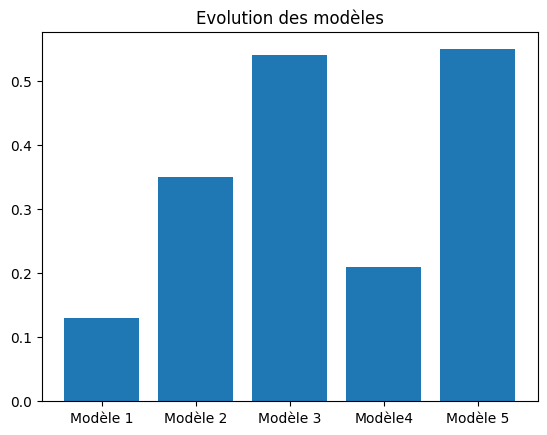

In [ ]:
# Evolution des 4 modèles
#import matplotlib.pyplot as plt
plt.bar(['Modèle 1', 'Modèle 2', 'Modèle 3', 'Modèle4', 'Modèle 5'], [0.13, 0.35, 0.54, 0.21, 0.5495], label='test_acc', align='center')
plt.title('Evolution des modèles')

ous constatons que pour notre exemple de fine-tuning, les performances du modèle s'améliorent : son accuracy est passée à 54,95%. Les courbes montrent que le modèle apprend bien les données d'entraînement mais rencontre des difficultés sur celles de validation. Ce problème d'instabilité qui persiste pourrait être dû à la grande variabilité intra-classe ainsi qu'aux similitudes entre certaines classes du dataset.


# Modèle 6 : modèle plus profond, ajout de couches denses


In [ ]:
# numbre de lessions = nombre de classes
NB_CLASSES = 9

model = models.Sequential([
 base_model,
 layers.Flatten(),
 layers.Dense(1000, activation='relu'),
 layers.Dropout(0.5),
 layers.Dense(500, activation='relu'),
 layers.Dropout(0.32),
 layers.Dense(250, activation='relu'),
 layers.Dropout(0.2),
 layers.Dense(NB_CLASSES, activation='softmax')
])

# # compiling the model
model.compile(optimizer='SGD', loss='categorical_crossentropy',metrics=['accuracy'])


#training the model
EPOCHS = 50


##################################################################

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

callbacks = [es, model_checkpoint];

history=model.fit(train_generator, epochs=EPOCHS,verbose=1 ,validation_data=val_generator,callbacks=callbacks)
print(history.history.keys())

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.2040 - loss: 2.0815

59/59 ━━━━━━━━━━━━━━━━━━━━ 50s 742ms/step - accuracy: 0.2641 - loss: 1.9793 - val_accuracy: 0.3562 - val_loss: 1.7644
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.4051 - loss: 1.7213

59/59 ━━━━━━━━━━━━━━━━━━━━ 38s 624ms/step - accuracy: 0.4038 - loss: 1.7049 - val_accuracy: 0.4163 - val_loss: 1.6056
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.4290 - loss: 1.6017

59/59 ━━━━━━━━━━━━━━━━━━━━ 39s 651ms/step - accuracy: 0.4538 - loss: 1.5500 - val_accuracy: 0.5150 - val_loss: 1.4936
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.4945 - loss: 1.4339

59/59 ━━━━━━━━━━━━━━━━━━━━ 37s 621ms/step - accuracy: 0.5011 - loss: 1.4303 - val_accuracy: 0.5064 - val_loss: 1.4445
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.4965 - loss: 1.3975

...

59/59 ━━━━━━━━━━━━━━━━━━━━ 38s 642ms/step - accuracy: 0.5786 - loss: 1.2020 - val_accuracy: 0.5579 - val_loss: 1.3225
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 36s 608ms/step - accuracy: 0.6105 - loss: 1.1237 - val_accuracy: 0.5236 - val_loss: 1.3674
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.6204 - loss: 1.1174

59/59 ━━━━━━━━━━━━━━━━━━━━ 38s 644ms/step - accuracy: 0.6169 - loss: 1.1215 - val_accuracy: 0.5279 - val_loss: 1.2946
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.6524 - loss: 1.0008

59/59 ━━━━━━━━━━━━━━━━━━━━ 37s 624ms/step - accuracy: 0.6392 - loss: 1.0263 - val_accuracy: 0.5708 - val_loss: 1.2737
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 38s 636ms/step - accuracy: 0.6621 - loss: 1.0033 - val_accuracy: 0.5236 - val_loss: 1.4043
Epoch 12/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 36s 593ms/step - accuracy: 0.6679 - loss: 0.9277 - val_accuracy: 0.5365 - val_loss: 1.3288
Epoch 13/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.6975 - loss: 0.8995

59/59 ━━━━━━━━━━━━━━━━━━━━ 37s 619ms/step - accuracy: 0.6897 - loss: 0.9122 - val_accuracy: 0.5622 - val_loss: 1.2643
Epoch 14/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 35s 600ms/step - accuracy: 0.6833 - loss: 0.8764 - val_accuracy: 0.5665 - val_loss: 1.2873
Epoch 15/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.7136 - loss: 0.8221

59/59 ━━━━━━━━━━━━━━━━━━━━ 36s 616ms/step - accuracy: 0.7179 - loss: 0.8146 - val_accuracy: 0.5665 - val_loss: 1.2566
Epoch 16/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 39s 576ms/step - accuracy: 0.7295 - loss: 0.7841 - val_accuracy: 0.5536 - val_loss: 1.3528
Epoch 17/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 35s 598ms/step - accuracy: 0.7412 - loss: 0.7279 - val_accuracy: 0.5579 - val_loss: 1.3797
Epoch 18/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 34s 578ms/step - accuracy: 0.7359 - loss: 0.7249 - val_accuracy: 0.5751 - val_loss: 1.3562
Epoch 19/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 34s 572ms/step - accuracy: 0.7651 - loss: 0.6633 - val_accuracy: 0.5880 - val_loss: 1.3286
Epoch 20/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 36s 600ms/step - accuracy: 0.7625 - loss: 0.6561 - val_accuracy: 0.5708 - val_loss: 1.2872
Epoch 20: early stopping
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## Évaluation et analyse modèle 6

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 557ms/step - accuracy: 0.6033 - loss: 1.1710
Test accuracy: 0.6033057570457458


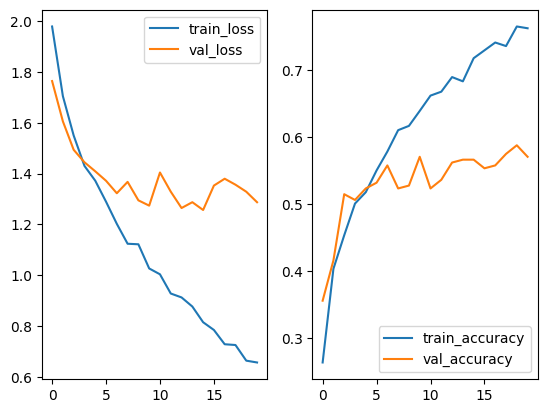

In [ ]:
#evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print('Test accuracy:', test_acc)

#tracer des courbes
plt.figure()
plt.subplot(121)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()


plt.subplot(122)
plt.plot(history.history['accuracy'], label='train_accuracy' )
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Evolution des modèles')

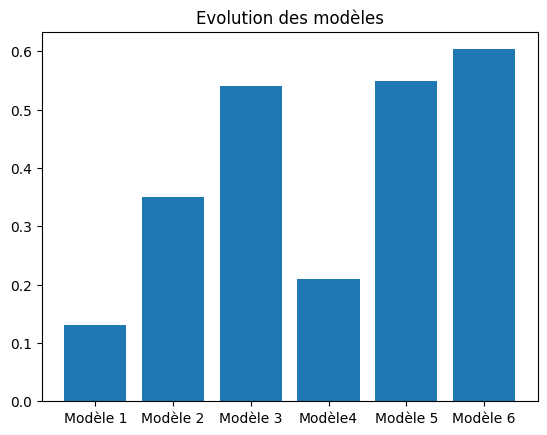

In [ ]:
# Evolution des 6 modèles
#import matplotlib.pyplot as plt
plt.bar(['Modèle 1', 'Modèle 2', 'Modèle 3', 'Modèle4', 'Modèle 5', 'Modèle 6'], [0.13, 0.35, 0.54, 0.21, 0.5495, 0.6033], label='test_acc', align='center')
plt.title('Evolution des modèles')

Nous constatons que le fait d'avoir un modèle plus profond a légèrement amélioré les performances, passant de 54,95% à 60,33%. Cependant, les courbes de val_loss et d'accuracy montrent que le problème persiste toujours : il existe un écart entre les performances d'entraînement et de validation, signe d'overfitting. Nous allons donc essayer de corriger la variabilité qui se trouve dans les classes en faisant de la data augmentation, en appliquant de simples rotations pour générer de nouvelles images et ainsi rééquilibrer le dataset.

# Problème avec la base de données


Notre base de donnee est tres desiquilibre, nous avons pour certainnes classes assez d'images depassant les 400 et pour certaine classe tres peut d'images voir moin de 100. le diamme circulaire ci dessous montre la repartition des images par classes que nous avons compté manuellement.

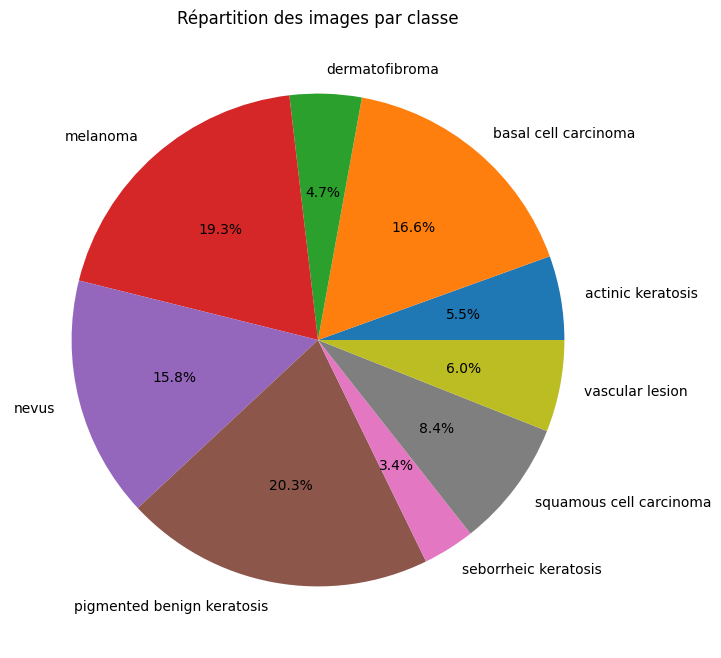

In [ ]:
classes = ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma',
           'melanoma', 'nevus', 'pigmented benign keratosis',
           'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']

effectifs = [130, 392, 111, 454, 373, 478, 80, 197, 142]

plt.figure(figsize=(8, 8))
plt.pie(effectifs, labels=classes, autopct='%1.1f%%')
plt.title('Répartition des images par classe')
plt.show()

# Solution : data augmentation et rééquilibrage des classes


En effectuant notre data augmentation, nous fixons le nombre d’images à 1000 pour chaque classe et, pour la rotation, la probabilité est fixée à 1 afin de s’assurer que l’opération va être effectuée sur toutes les images.


In [ ]:
# Augmentation des données

# Chemin d’accès pour le dossier d’entrée et le dossier de sortie pour les données augmentées
input_d = '/content/drive/MyDrive/Colab Notebooks/DATA2/'
output_d = '/content/drive/MyDrive/Colab Notebooks/DATA_AUG/'

# Chemin pour le split
data_dir = '/content/drive/MyDrive/Colab Notebooks/DATA_AUG/'
output_dir = '/content/drive/MyDrive/Colab Notebooks/DATA_AUG_SPLIT'

# Création d’un tableau avec le nom de chaque classe qui se trouve dans le dossier input
classes = [
    "actinic keratosis", "basal cell carcinoma", "dermatofibroma",
    "melanoma", "nevus", "pigmented benign keratosis",
    "seborrheic keratosis", "squamous cell carcinoma", "vascular lesion"]

# Boucle pour parcourir toutes les classes et faire l’augmentation dessus

for i in classes:
    P = Augmentor.Pipeline(input_d + i, output_d + i)
    P.rotate(probability=1, max_left_rotation=5, max_right_rotation=10)

    P.sample(1000)

splitfolders.ratio(data_dir, output_dir, seed=1337, ratio=(0.8, 0.1, 0.1))

Initialised with 130 image(s) found.
Output directory set to /content/drive/MyDrive/Colab Notebooks/DATA_AUG/actinic keratosis.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7A16BDC7B710>: 100%|██████████| 1000/1000 [00:52<00:00, 18.89 Samples/s]


Initialised with 392 image(s) found.
Output directory set to /content/drive/MyDrive/Colab Notebooks/DATA_AUG/basal cell carcinoma.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7A181D8F4C20>: 100%|██████████| 1000/1000 [00:55<00:00, 18.15 Samples/s]


Initialised with 111 image(s) found.
Output directory set to /content/drive/MyDrive/Colab Notebooks/DATA_AUG/dermatofibroma.

...

Processing <PIL.Image.Image image mode=RGB size=1024x768 at 0x7A176792E180>: 100%|██████████| 1000/1000 [01:53<00:00,  8.81 Samples/s]


Initialised with 197 image(s) found.
Output directory set to /content/drive/MyDrive/Colab Notebooks/DATA_AUG/squamous cell carcinoma.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7A1767950DA0>: 100%|██████████| 1000/1000 [02:28<00:00,  6.75 Samples/s]


Initialised with 142 image(s) found.
Output directory set to /content/drive/MyDrive/Colab Notebooks/DATA_AUG/vascular lesion.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7A176443D610>: 100%|██████████| 1000/1000 [00:47<00:00, 20.89 Samples/s]
Copying files: 9000 files [03:29, 43.01 files/s]


## rééquilibrage des classes après data augmentation

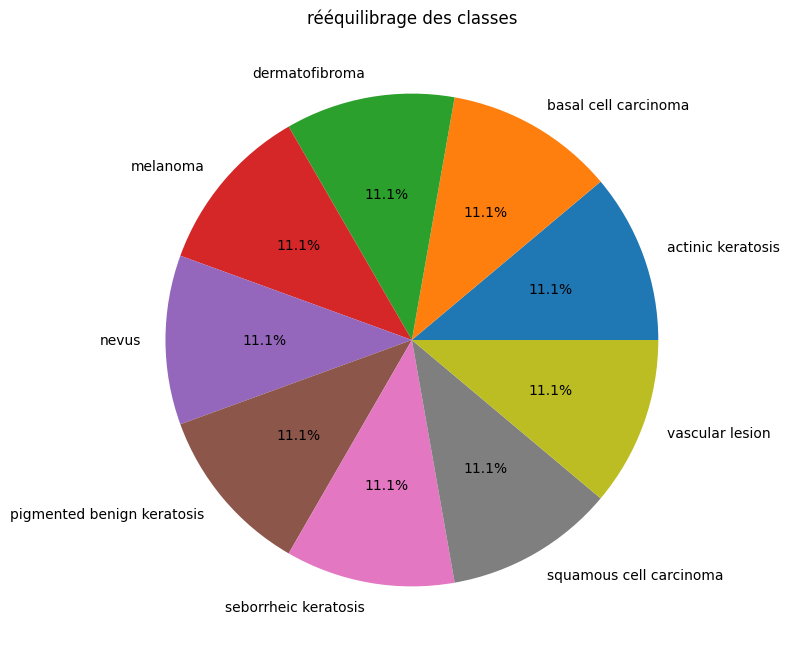

In [ ]:
classes = ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma',
           'melanoma', 'nevus', 'pigmented benign keratosis',
           'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']

effectifs = [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]

plt.figure(figsize=(8, 8))
plt.pie(effectifs, labels=classes, autopct='%1.1f%%')
plt.title('rééquilibrage des classes')
plt.show()

## Visualisation de la base de données après data augmentation


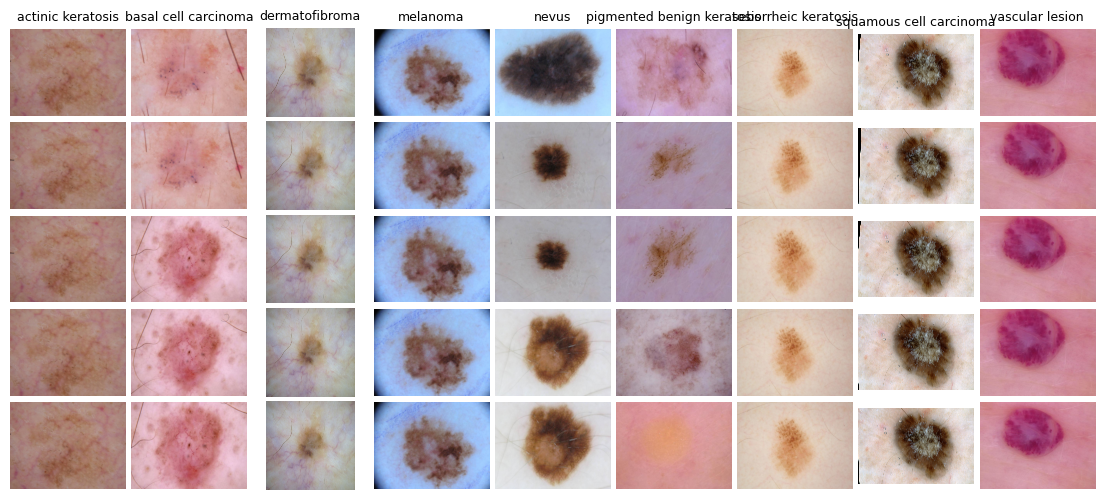

In [ ]:
data_dir = "/content/drive/MyDrive/Colab Notebooks/DATA_AUG"

classes = sorted(os.listdir(data_dir))

fig, axes = plt.subplots(5, len(classes), figsize=(14, 6))

for j, classe in enumerate(classes):
    classe_dir = os.path.join(data_dir, classe)

    # tri
    images = sorted(os.listdir(classe_dir))[:5]

    for i, img_name in enumerate(images):
        img_path = os.path.join(classe_dir, img_name)

        try:
            img = mpimg.imread(img_path)
            axes[i, j].imshow(img)
        except:
            axes[i, j].text(0.5, 0.5, "Erreur", ha='center')

        axes[i, j].axis('off')

        if i == 0:
            axes[i, j].set_title(classe, fontsize=9)

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

## Nouveau prétraitement sur les données augmentées


In [ ]:

#### pretraitement des donnees
datagen = ImageDataGenerator(rescale=1./255)

##

train_generator=datagen.flow_from_directory(
    directory ="/content/drive/MyDrive/Colab Notebooks/DATA_AUG_SPLIT/train",
    batch_size=32,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode="categorical",
    shuffle=True,
    seed=42
    )

test_generator=datagen.flow_from_directory(
    directory ="/content/drive/MyDrive/Colab Notebooks/DATA_AUG_SPLIT/test",
    batch_size=32,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode="categorical",
    shuffle=False,
    seed=42
    )


val_generator=datagen.flow_from_directory(
    directory ="/content/drive/MyDrive/Colab Notebooks/DATA_AUG_SPLIT/val",
    batch_size=32,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode="categorical",
    shuffle=True,
    seed=42
    )

Found 7200 images belonging to 9 classes.
Found 900 images belonging to 9 classes.
Found 900 images belonging to 9 classes.


# Modèle 7 : Fine tuning avec les données augmentées


In [ ]:
# numbre de lessions = nombre de classes
NB_CLASSES = 9

model = models.Sequential([
 base_model,
 layers.Flatten(),
 layers.Dense(500, activation='relu'),
 layers.Dropout(0.5),
 # layers.Dense(250, activation='relu'),
 # layers.Dropout(0.32),
 # layers.Dense(125, activation='relu'),
 # layers.Dropout(0.2),
 #layers.Dense(20, activation='relu'),
 layers.Dense(NB_CLASSES, activation='softmax')
])

# # compiling the model
model.compile(optimizer='SGD', loss='categorical_crossentropy',metrics=['accuracy'])


#training the model
EPOCHS = 50


##################################################################

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

callbacks = [es, model_checkpoint];

history=model.fit(train_generator, epochs=EPOCHS,verbose=1 ,validation_data=val_generator,callbacks=callbacks)
print(history.history.keys())

Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.4058 - loss: 1.6638

225/225 ━━━━━━━━━━━━━━━━━━━━ 87s 365ms/step - accuracy: 0.4954 - loss: 1.4156 - val_accuracy: 0.6544 - val_loss: 1.0077
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.6504 - loss: 1.0074

225/225 ━━━━━━━━━━━━━━━━━━━━ 80s 355ms/step - accuracy: 0.6617 - loss: 0.9637 - val_accuracy: 0.7311 - val_loss: 0.8456
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.7362 - loss: 0.7928

225/225 ━━━━━━━━━━━━━━━━━━━━ 77s 343ms/step - accuracy: 0.7422 - loss: 0.7621 - val_accuracy: 0.8178 - val_loss: 0.6241
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.7975 - loss: 0.6339

225/225 ━━━━━━━━━━━━━━━━━━━━ 82s 361ms/step - accuracy: 0.7957 - loss: 0.6334 - val_accuracy: 0.8189 - val_loss: 0.5798
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.8223 - loss: 0.5477

...

225/225 ━━━━━━━━━━━━━━━━━━━━ 78s 348ms/step - accuracy: 0.8999 - loss: 0.3216 - val_accuracy: 0.9056 - val_loss: 0.3586
Epoch 10/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.9045 - loss: 0.2937

225/225 ━━━━━━━━━━━━━━━━━━━━ 79s 349ms/step - accuracy: 0.9060 - loss: 0.2912 - val_accuracy: 0.8922 - val_loss: 0.3463
Epoch 11/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 76s 335ms/step - accuracy: 0.9160 - loss: 0.2667 - val_accuracy: 0.8889 - val_loss: 0.3512
Epoch 12/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.9334 - loss: 0.2256

225/225 ━━━━━━━━━━━━━━━━━━━━ 76s 338ms/step - accuracy: 0.9258 - loss: 0.2356 - val_accuracy: 0.9144 - val_loss: 0.3079
Epoch 13/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 76s 338ms/step - accuracy: 0.9282 - loss: 0.2252 - val_accuracy: 0.8989 - val_loss: 0.3199
Epoch 14/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.9353 - loss: 0.2045

225/225 ━━━━━━━━━━━━━━━━━━━━ 76s 335ms/step - accuracy: 0.9331 - loss: 0.2066 - val_accuracy: 0.9089 - val_loss: 0.2952
Epoch 15/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9398 - loss: 0.1900

225/225 ━━━━━━━━━━━━━━━━━━━━ 83s 341ms/step - accuracy: 0.9342 - loss: 0.1970 - val_accuracy: 0.9289 - val_loss: 0.2678
Epoch 16/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 82s 364ms/step - accuracy: 0.9394 - loss: 0.1881 - val_accuracy: 0.9200 - val_loss: 0.2853
Epoch 17/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 80s 355ms/step - accuracy: 0.9444 - loss: 0.1742 - val_accuracy: 0.9189 - val_loss: 0.2840
Epoch 18/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 85s 379ms/step - accuracy: 0.9458 - loss: 0.1668 - val_accuracy: 0.9233 - val_loss: 0.2792
Epoch 19/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 86s 383ms/step - accuracy: 0.9482 - loss: 0.1561 - val_accuracy: 0.9078 - val_loss: 0.2778
Epoch 20/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 86s 383ms/step - accuracy: 0.9490 - loss: 0.1507 - val_accuracy: 0.9256 - val_loss: 0.2698
Epoch 20: early stopping
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [ ]:
# summary of the model
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 500)            │    12,544,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 9)              │         4,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,263,699 (104.00 MB)

 Trainable params: 14,908,817 (56.87 MB)

 Non-trainable params: 12,354,880 (47.13 MB)

 Optimizer params: 2 (12.00 B)

## Évaluation et analyse Modèle 7

29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 315ms/step - accuracy: 0.9156 - loss: 0.2888
Test accuracy: 0.9155555367469788


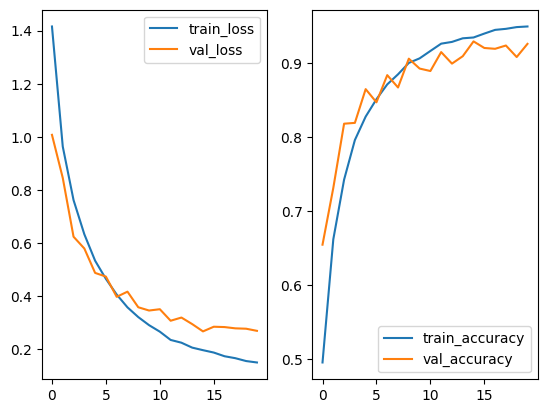

In [ ]:
#evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print('Test accuracy:', test_acc)

#tracer des courbes
plt.figure()
plt.subplot(121)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()


plt.subplot(122)
plt.plot(history.history['accuracy'], label='train_accuracy' )
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Evolution des modèles')

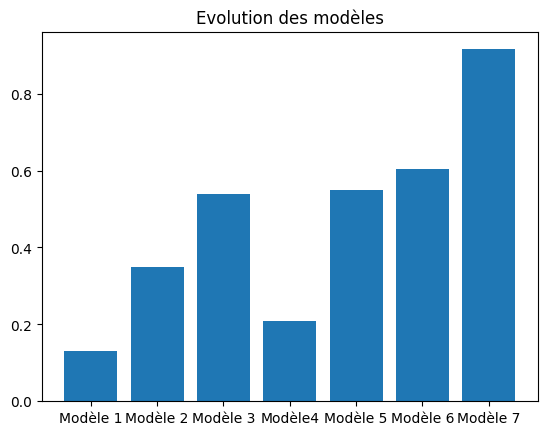

In [ ]:
# Evolution des 6 modèles
#import matplotlib.pyplot as plt
plt.bar(['Modèle 1', 'Modèle 2', 'Modèle 3', 'Modèle4', 'Modèle 5', 'Modèle 6', 'Modèle 7'], [0.13, 0.35, 0.54, 0.21, 0.5495, 0.6033, 0.9155], label='test_acc', align='center')
plt.title('Evolution des modèles')

Nous constatons une très grande amélioration des performances du modèle sur les données de test. La data augmentation a permis de passer de pratiquement 60 % à 91 %. L’analyse des courbes de loss et d’accuracy montre un apprentissage qui semble stable malgré de légères oscillations. Les courbes indiquent que le modèle a en effet convergé et qu’il parvient à généraliser sur les données de validation. Nous allons dans la suite le sauvegarder et effectuer une analyse détaillée.


## Sauvegarde du Modele

In [ ]:
# Sauvegarde architecture et poids dans deux fichier distincs
model_json = model.to_json()
with open('model.json', 'w') as json_file:
    json_file.write(model_json)
    model.save_weights('model.h5')

ValueError: The filename must end in `.weights.h5`. Received: filepath=model.h5

Les versions de Keras posent problème lors de la sauvegarde. Dans un workflow de deep learning, il est très important de respecter le cahier des charges afin que son travail puisse s’intégrer facilement dans le workflow. Afin de pouvoir respecter la sauvegarde des fichiers en deux fichiers distincts, l’un pour l’architecture en « .json » et l’autre pour les poids en « .h5 », nous avons repris l’entraînement sur les machines de la FSI.


# Evaluation des performances du modèle final

## Visualisation des filtres et des caractéristiques extraites par le réseau

Les réseaux de neurones sont généralement qualifiés d’opaques : il est difficile d’expliquer pourquoi
une décision spécifique a été prise. Dans le cas des réseaux convolutifs, il est possible de visualiser les
filtres entraînés dans chaque couche convolutive, et les cartes de caractéristiques résultant de
l’application de ces filtres aux images d’entrée. Ceci permet de fournir un aperçu de la
représentation interne du modèle.

In [ ]:
model.summary()

base_model = model.layers[0]
base_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 500)            │    12,544,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 9)              │         4,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,172,516 (160.88 MB)

 Trainable params: 14,908,817 (56.87 MB)

 Non-trainable params: 12,354,880 (47.13 MB)

...

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 2,359,808 (9.00 MB)

 Non-trainable params: 12,354,880 (47.13 MB)

L'analyse de l’architecture complète du modèle à l’aide de model.summary()   permet de distinguer deux parties principales : un réseau pré-entraîné VGG16 utilisé pour l’extraction des caractéristiques et des couches connectées pour la classification.

La partie VGG16 prend en entrée des images de taille 224×224 en RGB et extrait progressivement des caractéristiques à travers plusieurs blocs convolutifs et de pooling.

Ensuite, ces caractéristiques sont mis dans un vecteur de taille 25088 (flatten), puis passées dans une couche dense de 500 neurones, suivie d’un dropout pour limiter le surapprentissage. Enfin, une dernière couche dense de 9 neurones permet de réaliser la classification en 9 classes.

On observe que le modèle contient un grand nombre de paramètres (plus de 42 millions), mais seule une partie est entraînable ce qui permet de réduire le coût d’entraînement.

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,792 (7.00 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,792 (7.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,720 (151.25 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 38,720 (151.25 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


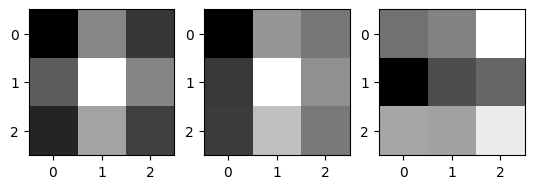

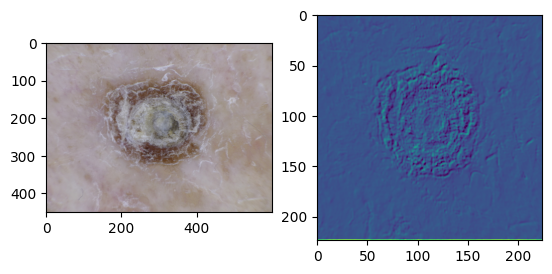

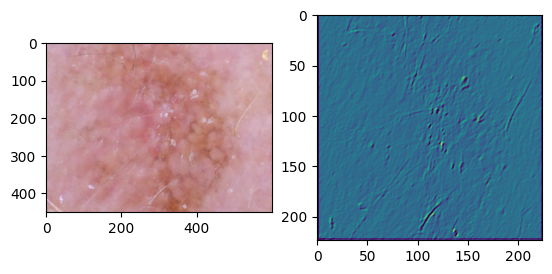

In [ ]:
# Récupérer les filtres et les poids de la 1ère couche

filters, biases, *is_anything_else_being_returned = base_model.layers[1].get_weights()
# normaliser les filtres sur [0 , 1]
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)
# Prendre le deuxième filtre de cette couche (qui contient 3 sous-filtres pour les 3 canaux R,
# V et et B) et visualiser ces 3 sous-filtres
f=filters[:,:,:,1]
plt.figure()
plt.subplot(1,3,1)
plt.imshow(f[:, :, 0], cmap='gray')
plt.subplot(1,3,2)
plt.imshow(f[:, :, 1], cmap='gray')
plt.subplot(1,3,3)
plt.imshow(f[:, :, 2], cmap='gray')


# Maintenant, on veut prendre une image et la mettre en entrée d’un seul filtre et voir ce qui est donné en sortie

# On importe l’image et on lui applique toutes les transformations que l’on a appliquées aux images pendant l’entraînement

img1 ='/content/drive/MyDrive/Colab Notebooks/DATA/Train/actinic keratosis/ISIC_0031430.jpg'
img2 ='/content/drive/MyDrive/Colab Notebooks/DATA_AUG_SPLIT/test/actinic keratosis/actinic keratosis_original_ISIC_0026650.jpg_0daf35c3-7b06-44ab-9af9-6cff447c6c26.jpg'

IMG1 = Image.open(img1)
IMG2 = Image.open(img2)
# pretraitement sur l'image1
image1 = np.asarray(IMG1)
image1=image1.astype('float32')
image1=cv2.resize(image1,(224,224))
image1 /= 255
image1 = image1.reshape([-1,224,224,3])

# pretraitement sur l'image2
image2 = np.asarray(IMG2)
image2=image2.astype('float32')
image2=cv2.resize(image2,(224,224))
image2 /= 255
image2 = image2.reshape([-1,224,224,3])

########### Définir un modèle intermédiaire contenant les 2 premières couches du modèle initial
inter_model = Model(inputs=base_model.inputs, outputs=base_model.layers[1].output)
inter_model.summary()
feature_maps = inter_model.predict(image1)

plt.figure()
plt.subplot(121)
plt.imshow(IMG1)
plt.subplot(122)
plt.imshow(feature_maps[0,:,:,0])

## Même chose pour l’image 2
inter_model = Model(inputs=base_model.inputs, outputs=base_model.layers[2].output)
inter_model.summary()
feature_maps = inter_model.predict(image2)

plt.figure()
plt.subplot(121)
plt.imshow(IMG2)
plt.subplot(122)
plt.imshow(feature_maps[0,:,:,0])


Les filtres de la première couche convolutive du modèle VGG16 (block1_conv1) ont été extraits et normalisés, chaque filtre est de dimension 3×3. Ceux ci sont appliques aux trois canaux de couleur (RGB). L’observation de ces filtres met en évidence des motifs  caractérisés par des variations d’intensité tres souvent des opérations de détection des contours, des transitions de luminosité ou les différences de couleur.

Par la suite, ces filtres ont été appliqués à des images issues de la base de test. Pour cela, un modèle intermédiaire a été défini afin de se limiter aux premières couches du réseau. Les images ont été préalablement redimensionnées et normalisées de manière identique aux données d’entraînement, garantissant ainsi la cohérence du traitement.

Les cartes de caractéristiques obtenues (feature maps) montrent que certaines régions de l’image sont fortement activées, tandis que d’autres sont atténuées. Ces activations correspondent aux zones où les motifs appris par les filtres sont présents. Ainsi, les premières couches du réseau extraient des informations locales liées aux textures et aux variations de couleur.

L’analyse des résultats après la deuxième couche convolutive (block1_conv2) révèle une structuration plus marquée des activations. Les cartes obtenues apparaissent moins bruitées et mettent en évidence des motifs plus organisés. Cela s’explique par le fait que les couches successives combinent progressivement les informations extraites, permettant une représentation de plus en plus abstraite de l’image.

# MATRICE DE CONFUSION

In [ ]:
from sklearn.metrics import confusion_matrix
test_images = test_generator


y_pred_prob=model.predict(test_images)

29/29 ━━━━━━━━━━━━━━━━━━━━ 615s 21s/step


In [ ]:

from sklearn.metrics import confusion_matrix
test_images = test_generator


y_pred_prob=model.predict(test_images)





29/29 ━━━━━━━━━━━━━━━━━━━━ 539s 19s/step


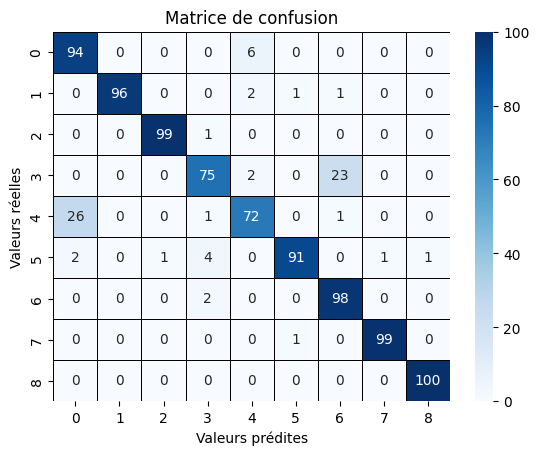

In [ ]:

y_pred=np.argmax(y_pred_prob, 1)

labels = test_images.classes

mat = confusion_matrix(labels, y_pred)

# Affichage
plt.figure()
sns.heatmap(mat, annot=True, fmt='d', cmap='Blues', linewidths=0.5, linecolor='black')

plt.title("Matrice de confusion")
plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")

plt.show()



Les performances du modèle ont été évaluées à l’aide d’une matrice de confusion construite à partir des prédictions réalisées sur l’ensemble de test.

L’analyse de la matrice montre que la majorité des prédictions se situe sur la diagonale principale. Certaines classes, comme les classes 2, 7 et 8, correspondant respectivement a dermatofibroma; squamous cell carcinoma et vascular lesion présentent des performances quasi parfaites, avec très peu d’erreurs de classification.

En revanche, des confusions apparaissent pour certaines classes. Par exemple, la classe 3 (melanoma) est fréquemment confondue avec la classe 6 (seborrheic) (23 erreurs), ce qui est tres dengeureux pour notre cas. en effet la classe 3 melanoma est une classe cancereuse et devrais pouvoir etre discriminer parfaitement pour un bon diagnostique.


 De même, la classe 4 présente plusieurs erreurs, notamment une confusion importante avec la classe 0 (26 erreurs), indiquant que ces deux classes partagent des caractéristiques visuelles proches.

Certaines classes comme la classe 5 montrent des erreurs plus dispersées, traduisant une difficulté plus générale du modèle à bien discriminer cette catégorie.

In [ ]:
classe = ["actinic keratosis", "basal cell carcinoma", "dermatofibroma",
          "melanoma", "nevus", "pigmented benign keratosis", "seborrheic keratosis",
          "squamous cell carcinoma", "vascular lesion"]

### Calcul des metriques

In [ ]:
# Affichage des metriques

from sklearn.metrics import classification_report

print(classification_report(labels, y_pred))



              precision    recall  f1-score   support

           0       0.77      0.94      0.85       100
           1       1.00      0.96      0.98       100
           2       0.99      0.99      0.99       100
           3       0.90      0.75      0.82       100
           4       0.88      0.72      0.79       100
           5       0.98      0.91      0.94       100
           6       0.80      0.98      0.88       100
           7       0.99      0.99      0.99       100
           8       0.99      1.00      1.00       100

    accuracy                           0.92       900
   macro avg       0.92      0.92      0.91       900
weighted avg       0.92      0.92      0.91       900



\Les performances du modèle sont évaluées à l’aide de plusieurs métriques issues du rapport de classification.

* **La précision (precision)** : parmi ce que le modèle a prédit comme étant une classe, combien sont réellement corrects.

* **Rappel (Recall)** : parmi tous les vrais éléments d’une classe, combien le modèle a réussi à retrouver.

* **F1-score** : moyenne entre la précision et le rappel.

* **Accuracy (exactitude globale)** : pourcentage total de bonnes prédictions.

* **Macro average**: moyenne des scores calculée en donnant le même poids à chaque classe.

* **Weighted average** : moyenne des scores pondérée par le nombre d’exemples de chaque classe.






Le modèle présente une performance globale d’environ 92% (accuracy) et un F1-score élevé, ce qui indique une bonne capacité de classification sur l’ensemble des données. Cependant, certaines classes ont un recall plus faible (autour de 0.72–0.75), ce qui signifie qu’une partie des cas réels n’est pas détectée. Dans un contexte de détection du cancer de la peau, ces faux négatifs sont critiques, car ils correspondent à des cas potentiellement non diagnostiqués. Ainsi, malgré des résultats globalement satisfaisants, le modèle n’est pas encore suffisamment fiable pour une utilisation médicale autonome.






Deploiement du Model

Le cahier des charge demande que  lors du deploiement du modele celui si  predise soit que le malade est sain soit qu'il est eteint d'un cancer et precise dans ce cas le cancer detecter.
Pour repondre a cette question, il est neccessaire de faire une analyse en peu plus precise du dataset fourni pour ce projet. A l'interieur de ce dataset nous avons des images repartis dans dans 09 classes differentes. Nous pouvons les regrouper en deux categories a savoir lessions malignes et les lessions benignes.
  

1.  *  **Lessions benignes :**  il s'agit ici des problemes dermatologique pour deriver vers des cancers mais qui ne sont encore a l'etapes du cancer.Parmis lesquels nous avons dermatofibroma, nevus, pigmented benign keratosis, seborrheic keratosis, vascular lesion.

2.  * **Lessions  Malignes :** ici nous avons a faire a des lessions avec deja a l'etapes de cancer. Et la nous avons actinic keratosis,basal cell carcinoma,melanoma, squamous cell carcinoma.





# Conclusion

 L'API conçue peut détecter la présence d'un cancer avec un recall moyen de 91%, obtenu en faisant la moyenne des recalls des 4 types de lésions cancéreuses : actinic keratosis (94%), basal cell carcinoma (96%), mélanome (75%) et squamous cell carcinoma (99%). Cela signifie que sur 100 patients atteints d'un cancer, le modèle en détecte correctement 91. Sur ces 91 patients détectés, le modèle sera capable d'identifier le type de cancer avec une précision de 100% pour le basal cell carcinoma, 99% pour le squamous cell carcinoma, 90% pour le mélanome et 77% pour l'actinic keratosis.
Il est important de noter que le mélanome présente le recall le plus faible avec 75%, ce qui signifie que 25 patients sur 100 atteints d'un mélanome ne seront pas détectés. Ce cas est cliniquement le plus préoccupant car le mélanome est le type de cancer cutané le plus dangereux. Notre application reste donc un outil d'aide au diagnostic et ne peut en aucun cas se substituer à l'avis d'un dermatologue.